In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/model_dataset.csv",
    index_col=0,
    parse_dates=True
)

print(df.shape)
df.head()

(2454, 18)


,Target_GK_Vol,Target_Vol_t1,AAPL_Return,Ret_Lag1,Ret_Lag5,Ret_Lag10,Vol_Roll5,Vol_Roll20,Vol_Roll60,Vol_Change,VIX_Close,VIX_Change,SPY_Return,SPY_Vol,MSFT_Return,MSFT_Vol,AAPL_Volume,Volume_Change
Date,,,,,,,,,,,,,,,,,,
2016-03-30,1.054690,0.512436,1.730836,2.339564,0.761877,1.989449,0.867093,0.975008,1.343805,-0.025540,13.56,-1.899248,0.437818,0.430684,0.619527,0.936978,182404400,0.379831
2016-03-31,0.512436,0.942546,-0.521597,1.730836,-0.554369,1.320394,0.819679,0.957179,1.325470,-0.018286,13.95,2.835518,-0.243004,0.351740,0.326437,0.879715,103553600,-0.566137
2016-04-01,0.942546,1.155689,0.913326,-0.521597,-0.434400,-0.160564,0.827529,0.970517,1.316621,0.013935,13.10,-6.286724,0.678862,0.760426,0.613720,1.200247,103496000,-0.000556
2016-04-04,1.155689,0.824183,1.022134,0.913326,-0.455278,0.113359,0.941198,0.948571,1.306780,-0.022612,14.12,7.497996,-0.324290,0.364468,-0.252242,0.843477,149424800,0.367260
2016-04-05,0.824183,1.067183,-1.185913,1.022134,2.339564,-0.009415,0.897909,0.926853,1.282988,-0.022896,15.42,8.807315,-1.003826,0.804057,-1.582015,0.813800,106314800,-0.340389


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Target_GK_Vol,2454.0,1.224744e+00,7.073465e-01,2.534050e-01,7.641319e-01,1.056816e+00,1.468881e+00,7.716490e+00
Target_Vol_t1,2454.0,1.224485e+00,7.075252e-01,2.534050e-01,7.640944e-01,1.056816e+00,1.468881e+00,7.716490e+00
AAPL_Return,2454.0,9.840107e-02,1.825987e+00,-1.377082e+01,-7.099355e-01,1.071152e-01,9.967739e-01,1.426174e+01
Ret_Lag1,2454.0,9.945579e-02,1.826534e+00,-1.377082e+01,-7.099355e-01,1.095322e-01,9.975590e-01,1.426174e+01
Ret_Lag5,2454.0,9.876037e-02,1.826650e+00,-1.377082e+01,-7.099355e-01,1.028018e-01,9.975590e-01,1.426174e+01
Ret_Lag10,2454.0,1.005555e-01,1.826930e+00,-1.377082e+01,-7.059171e-01,1.028018e-01,1.001851e+00,1.426174e+01
Vol_Roll5,2454.0,1.225008e+00,5.574470e-01,4.035867e-01,8.660203e-01,1.099590e+00,1.458989e+00,5.758285e+00
Vol_Roll20,2454.0,1.225154e+00,4.492818e-01,5.073520e-01,9.203013e-01,1.123987e+00,1.441305e+00,3.841655e+00
Vol_Roll60,2454.0,1.225910e+00,3.672326e-01,5.751023e-01,9.575914e-01,1.127503e+00,1.459353e+00,2.487728e+00
Vol_Change,2454.0,4.930346e-04,3.257403e-02,-1.706967e-01,-1.713436e-02,-7.372992e-04,1.669945e-02,2.134724e-01


In [3]:
corr = df.corr()

corr.round(3)

,Target_GK_Vol,Target_Vol_t1,AAPL_Return,Ret_Lag1,Ret_Lag5,Ret_Lag10,Vol_Roll5,Vol_Roll20,Vol_Roll60,Vol_Change,VIX_Close,VIX_Change,SPY_Return,SPY_Vol,MSFT_Return,MSFT_Vol,AAPL_Volume,Volume_Change
Target_GK_Vol,1.000,0.601,-0.123,-0.153,-0.060,-0.045,0.757,0.560,0.413,0.597,0.626,0.134,-0.147,0.738,-0.116,0.721,0.493,0.230
Target_Vol_t1,0.601,1.000,-0.153,-0.150,-0.084,-0.086,0.598,0.500,0.384,0.270,0.595,0.156,-0.193,0.564,-0.130,0.556,0.343,0.107
AAPL_Return,-0.123,-0.153,1.000,-0.054,0.022,-0.036,-0.039,-0.023,0.004,-0.088,-0.135,-0.545,0.755,-0.120,0.678,-0.136,-0.040,-0.054
Ret_Lag1,-0.153,-0.150,-0.054,1.000,-0.017,0.085,-0.078,-0.034,-0.002,-0.088,-0.098,0.084,-0.120,-0.143,-0.136,-0.148,-0.043,-0.010
Ret_Lag5,-0.060,-0.084,0.022,-0.017,1.000,0.022,-0.141,-0.062,-0.019,-0.049,-0.075,0.015,0.033,-0.105,0.019,-0.075,-0.033,0.033
Ret_Lag10,-0.045,-0.086,-0.036,0.085,0.022,1.000,-0.081,-0.087,-0.033,-0.034,-0.058,0.031,-0.032,-0.062,-0.058,-0.063,-0.038,0.001
Vol_Roll5,0.757,0.598,-0.039,-0.078,-0.141,-0.081,1.000,0.768,0.560,0.321,0.750,-0.036,-0.031,0.716,-0.019,0.659,0.390,-0.041
Vol_Roll20,0.560,0.500,-0.023,-0.034,-0.062,-0.087,0.768,1.000,0.785,0.047,0.779,-0.048,0.013,0.611,0.009,0.528,0.235,-0.030
Vol_Roll60,0.413,0.384,0.004,-0.002,-0.019,-0.033,0.560,0.785,1.000,-0.096,0.694,-0.042,0.029,0.453,0.012,0.370,0.090,-0.016
Vol_Change,0.597,0.270,-0.088,-0.088,-0.049,-0.034,0.321,0.047,-0.096,1.000,0.152,0.133,-0.121,0.340,-0.104,0.368,0.376,0.220


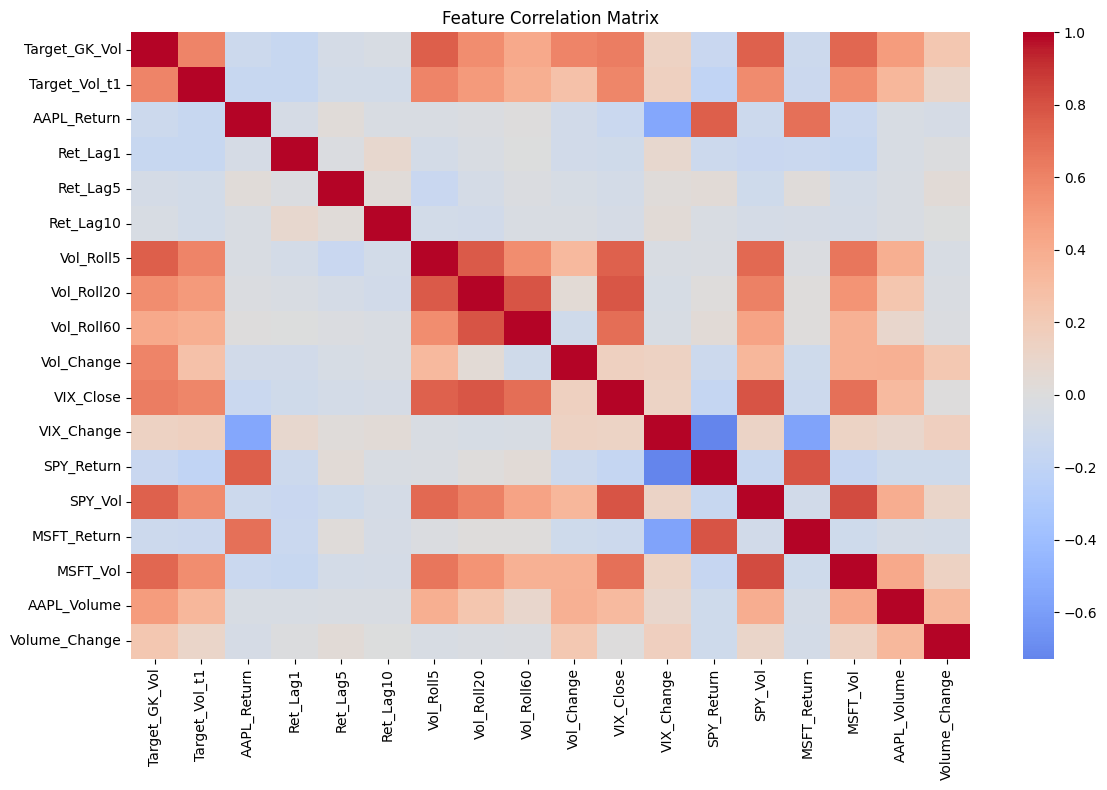

In [4]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "../figures/correlation_matrix.png"
)

plt.show()

In [5]:
target_corr = (
    corr["Target_Vol_t1"]
    .sort_values(ascending=False)
)

print(target_corr)

Target_Vol_t1    1.000000
Target_GK_Vol    0.601494
Vol_Roll5        0.598432
VIX_Close        0.594905
SPY_Vol          0.563747
MSFT_Vol         0.556152
Vol_Roll20       0.499823
Vol_Roll60       0.383979
AAPL_Volume      0.342568
Vol_Change       0.270341
VIX_Change       0.155786
Volume_Change    0.107110
Ret_Lag5        -0.083859
Ret_Lag10       -0.086039
MSFT_Return     -0.129583
Ret_Lag1        -0.150229
AAPL_Return     -0.153188
SPY_Return      -0.193017
Name: Target_Vol_t1, dtype: float64


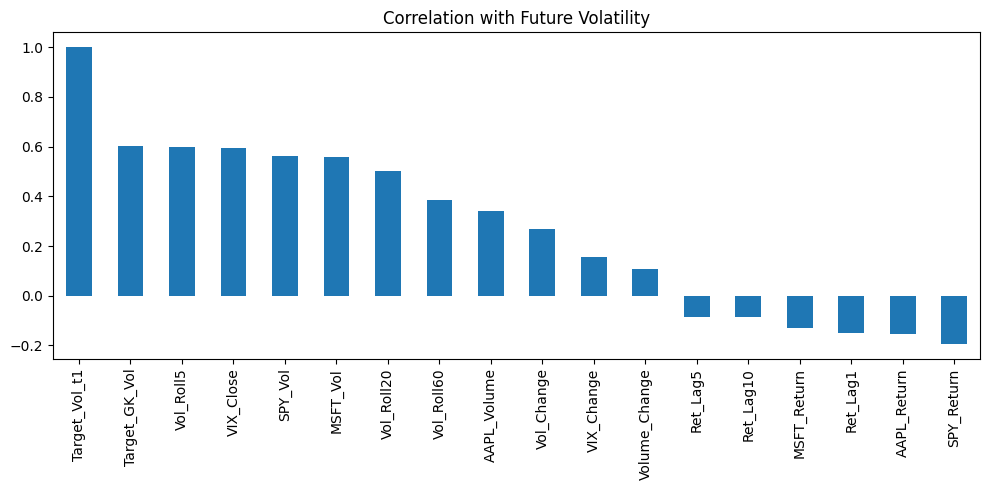

In [6]:
target_corr.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Correlation with Future Volatility"
)

plt.tight_layout()

plt.show()

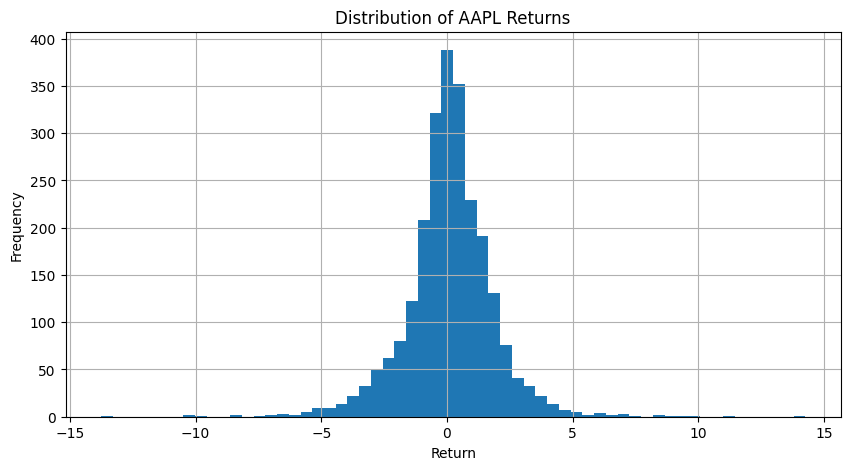

In [7]:
plt.figure(figsize=(10,5))

df["AAPL_Return"].hist(
    bins=60
)

plt.title(
    "Distribution of AAPL Returns"
)

plt.xlabel("Return")

plt.ylabel("Frequency")

plt.savefig(
    "../figures/returns_distribution.png"
)

plt.show()

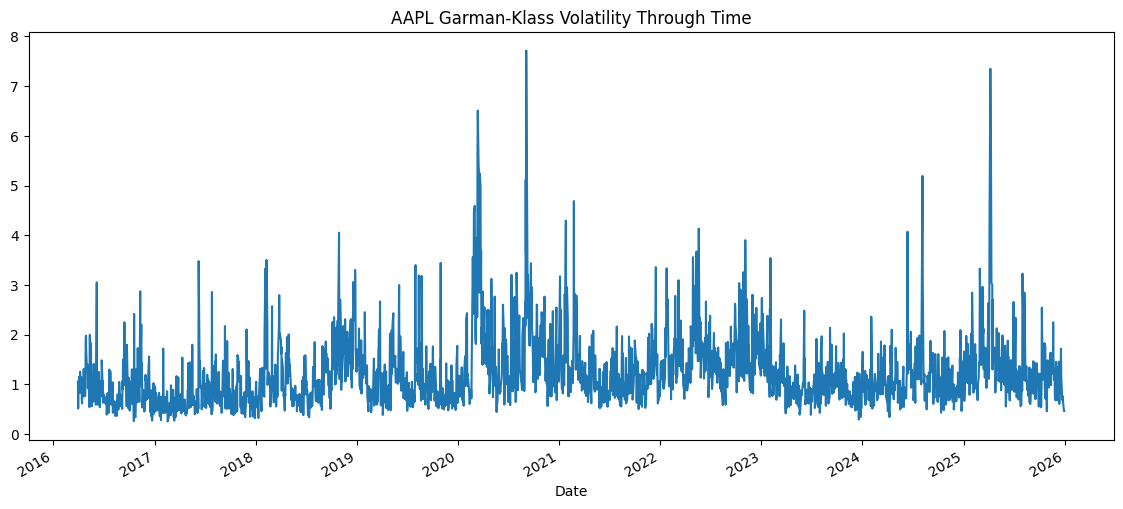

In [8]:
plt.figure(figsize=(14,6))

df["Target_GK_Vol"].plot()

plt.title(
    "AAPL Garman-Klass Volatility Through Time"
)

plt.savefig(
    "../figures/volatility_clustering.png"
)

plt.show()

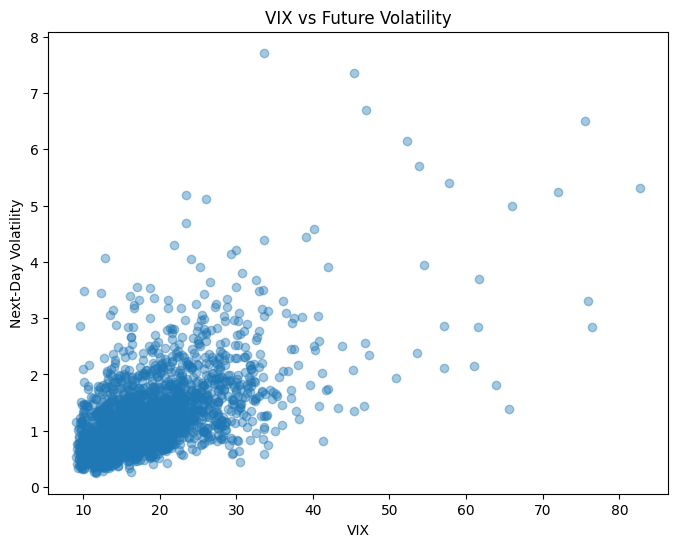

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["VIX_Close"],
    df["Target_Vol_t1"],
    alpha=0.4
)

plt.xlabel("VIX")

plt.ylabel("Next-Day Volatility")

plt.title(
    "VIX vs Future Volatility"
)

plt.savefig(
    "../figures/vix_vs_volatility.png"
)

plt.show()

In [10]:
feature_rank = (
    corr["Target_Vol_t1"]
    .abs()
    .sort_values(
        ascending=False
    )
)

print(feature_rank)

Target_Vol_t1    1.000000
Target_GK_Vol    0.601494
Vol_Roll5        0.598432
VIX_Close        0.594905
SPY_Vol          0.563747
MSFT_Vol         0.556152
Vol_Roll20       0.499823
Vol_Roll60       0.383979
AAPL_Volume      0.342568
Vol_Change       0.270341
SPY_Return       0.193017
VIX_Change       0.155786
AAPL_Return      0.153188
Ret_Lag1         0.150229
MSFT_Return      0.129583
Volume_Change    0.107110
Ret_Lag10        0.086039
Ret_Lag5         0.083859
Name: Target_Vol_t1, dtype: float64
